In [2]:
import pandas as pd

# File path
csv_file = "snomad_snocvr_obs_202409_202505.csv"

# Read only a sample first for quick inspection
df_sample = pd.read_csv(csv_file, nrows=5)
print("Columns:")
print(df_sample.columns.tolist())
print("\nSample rows:")
print(df_sample)


Columns:
['station_id', 'valid_time', 'lat', 'lon', 'elev_m', 'obs_totalSnowDepth_mm', 'effqc0', 'effqc1', 'efferr0', 'efferr1', 'flag_elevation_bkgdiff', 'flag_rejectlist', 'flag_invalid_elevation', 'flag_landice_check', 'flag_missing_snowdepth', 'flag_seaice_check', 'flag_invalid_snowdepth', 'flag_temporal_thinning', 'flag_land_check', 'flag_background_check', 'flag_missing_elevation', 'source_file', 'month', 'cycle']

Sample rows:
  station_id                 valid_time        lat         lon       elev_m  \
0      MRHU1  2024-08-31 21:00:00+00:00  40.984921 -110.850754  2438.399902   
1      SMLO3  2024-08-31 21:00:00+00:00  43.449070 -122.138077  1709.900024   
2      MRHU1  2024-08-31 22:00:00+00:00  40.984921 -110.850754  2438.399902   
3      BMNC2  2024-08-31 21:00:00+00:00  40.887901 -105.664040  2737.100098   
4      HNSW4  2024-08-31 21:00:00+00:00  44.256020 -106.979828  2548.100098   

   obs_totalSnowDepth_mm  effqc0  effqc1       efferr0       efferr1  ...  \
0         

In [3]:
import pandas as pd
import numpy as np

csv_file = "snomad_snocvr_obs_202409_202505.csv"

flag_cols = [
    "flag_elevation_bkgdiff",
    "flag_rejectlist",
    "flag_invalid_elevation",
    "flag_landice_check",
    "flag_missing_snowdepth",
    "flag_seaice_check",
    "flag_invalid_snowdepth",
    "flag_temporal_thinning",
    "flag_land_check",
    "flag_background_check",
    "flag_missing_elevation",
]

keep_cols = [
    "station_id",
    "valid_time",
    "lat",
    "lon",
    "elev_m",
    "obs_totalSnowDepth_mm",
    "month",
    "cycle",
] + flag_cols

df0 = pd.read_csv(csv_file, usecols=keep_cols)

df0["station_id"] = df0["station_id"].astype(str).str.strip()
df0["valid_time"] = pd.to_datetime(df0["valid_time"], errors="coerce", utc=True)
df0["obs_totalSnowDepth_mm"] = pd.to_numeric(df0["obs_totalSnowDepth_mm"], errors="coerce")

missing_sentinel = -3.368795e38
df0.loc[df0["obs_totalSnowDepth_mm"] <= missing_sentinel / 10, "obs_totalSnowDepth_mm"] = np.nan

# physical sanity filter
df0["snow_depth_mm_raw"] = df0["obs_totalSnowDepth_mm"]
df0["obs_totalSnowDepth_mm"] = df0["obs_totalSnowDepth_mm"].where(
    (df0["obs_totalSnowDepth_mm"] >= 0) & (df0["obs_totalSnowDepth_mm"] <= 20000),
    np.nan
)

# clean flags
for c in flag_cols:
    df0[c] = pd.to_numeric(df0[c], errors="coerce").fillna(0).astype(int)

# drop rows missing core fields
df0 = df0.dropna(subset=["station_id", "valid_time", "obs_totalSnowDepth_mm"]).copy()

# assimilation keep/reject
df0["is_rejected_assim"] = df0[flag_cols].max(axis=1).astype(int)
df0["is_kept_assim"] = 1 - df0["is_rejected_assim"]

df0 = df0.sort_values(["station_id", "valid_time"]).reset_index(drop=True)

print("Rows:", len(df0))
print("Stations:", df0["station_id"].nunique())
print("\nAssimilation keep/reject counts:")
print(df0["is_rejected_assim"].value_counts().sort_index())

print("\nFraction kept for assimilation:")
print(df0["is_kept_assim"].mean())

print("\nTop flag totals:")
print(df0[flag_cols].sum().sort_values(ascending=False))

Rows: 21641629
Stations: 10798

Assimilation keep/reject counts:
is_rejected_assim
0     1122841
1    20518788
Name: count, dtype: int64

Fraction kept for assimilation:
0.05188338641236295

Top flag totals:
flag_temporal_thinning    19905506
flag_background_check       443828
flag_invalid_elevation      122766
flag_land_check              17472
flag_elevation_bkgdiff       11424
flag_seaice_check            10071
flag_landice_check            7721
flag_rejectlist                  0
flag_missing_snowdepth           0
flag_invalid_snowdepth           0
flag_missing_elevation           0
dtype: int64


### Physical Sanity Check: set boundaries for unphysical data. Min = 0, Max = 20000

In [4]:
df["snow_depth_mm_raw"] = df["obs_totalSnowDepth_mm"]

# Basic physical sanity bounds for exploratory analysis
# Keep this conservative for now
df["obs_totalSnowDepth_mm"] = df["obs_totalSnowDepth_mm"].where(
    (df["obs_totalSnowDepth_mm"] >= 0) & (df["obs_totalSnowDepth_mm"] <= 20000),
    pd.NA
)

n_bad_physical = df["obs_totalSnowDepth_mm"].isna().sum() - df["snow_depth_mm_raw"].isna().sum()
print("Rows newly set to missing by physical sanity filter:", n_bad_physical)

# Drop those rows for repeat-analysis prep
df = df.dropna(subset=["obs_totalSnowDepth_mm"]).copy()

print("Rows after physical sanity filter:", len(df))
print("\nUpdated snow depth summary:")
print(df["obs_totalSnowDepth_mm"].describe())

NameError: name 'df' is not defined

### Duplicate Check

In [5]:
df_kept = df0[df0["is_kept_assim"] == 1].copy()

dup_groups_kept = (
    df_kept.groupby(["station_id", "valid_time"])["obs_totalSnowDepth_mm"]
    .agg(["count", "nunique"])
    .reset_index()
)

same_value_dups_kept = dup_groups_kept[
    (dup_groups_kept["count"] > 1) & (dup_groups_kept["nunique"] == 1)
]
conflicting_dups_kept = dup_groups_kept[
    (dup_groups_kept["count"] > 1) & (dup_groups_kept["nunique"] > 1)
]

print("Kept obs rows:", len(df_kept))
print("Stations in kept data:", df_kept["station_id"].nunique())
print("Duplicate station/time groups with same value:", len(same_value_dups_kept))
print("Duplicate station/time groups with conflicting values:", len(conflicting_dups_kept))

Kept obs rows: 1122841
Stations in kept data: 10216
Duplicate station/time groups with same value: 0
Duplicate station/time groups with conflicting values: 0


## Step 2: station reporting style
tells us how a station tends to report before we accuse it of being “stuck.”

### Build station summary metrics

In [6]:
import pandas as pd
import numpy as np

# Start from assimilation-eligible data only
analysis_df = df_kept.copy()

# Sort for consistency
analysis_df = analysis_df.sort_values(["station_id", "valid_time"]).reset_index(drop=True)

# Reporting cadence
analysis_df["hours_since_prev"] = (
    analysis_df.groupby("station_id")["valid_time"]
    .diff()
    .dt.total_seconds()
    / 3600.0
)

station_basic = (
    analysis_df.groupby("station_id")
    .agg(
        n_obs=("obs_totalSnowDepth_mm", "size"),
        n_unique=("obs_totalSnowDepth_mm", "nunique"),
        min_snow_mm=("obs_totalSnowDepth_mm", "min"),
        max_snow_mm=("obs_totalSnowDepth_mm", "max"),
        median_snow_mm=("obs_totalSnowDepth_mm", "median"),
        pct_zero=("obs_totalSnowDepth_mm", lambda s: (s == 0).mean()),
        median_hours_between_reports=("hours_since_prev", "median"),
    )
    .reset_index()
)

# Unique nonzero counts
nonzero_unique = (
    analysis_df.loc[analysis_df["obs_totalSnowDepth_mm"] > 0]
    .groupby("station_id")["obs_totalSnowDepth_mm"]
    .nunique()
    .reset_index(name="n_unique_nonzero")
)

station_basic = station_basic.merge(nonzero_unique, on="station_id", how="left")
station_basic["n_unique_nonzero"] = station_basic["n_unique_nonzero"].fillna(0).astype(int)

print(station_basic.head(20))
print("\nSummary of basic station metrics:")
print(station_basic.describe(include="all"))

   station_id  n_obs  n_unique  min_snow_mm  max_snow_mm  median_snow_mm  \
0       0000O      4         4          0.0        220.0            55.0   
1       0006O      1         1         30.0         30.0            30.0   
2       0010H     84         7          0.0        230.0             0.0   
3       0013R      6         6          0.0        460.0           255.0   
4       0015R    169        29          0.0        390.0             0.0   
5       0018R     66        21          0.0        430.0            40.0   
6       001MD    676        15          0.0        230.0             0.0   
7       0021R     16        11         50.0        240.0           120.0   
8       0022B     23         6          0.0         70.0             0.0   
9       0024W    188         4          0.0         30.0             0.0   
10      002MD    661        28          0.0        270.0             0.0   
11      0033B      1         1        130.0        130.0           130.0   
12      0033

In [7]:
# Helper for "near a multiple"
def frac_near_multiple(series, base, tol=0.1):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    rem = np.mod(s, base)
    dist = np.minimum(rem, base - rem)
    return (dist <= tol).mean()

station_grid = (
    analysis_df.groupby("station_id")["obs_totalSnowDepth_mm"]
    .apply(lambda s: pd.Series({
        "pct_on_10mm_grid": frac_near_multiple(s, 10.0, tol=0.1),
        "pct_on_5mm_grid": frac_near_multiple(s, 5.0, tol=0.1),
        "pct_on_25p4mm_grid": frac_near_multiple(s, 25.4, tol=0.2),
        "pct_on_12p7mm_grid": frac_near_multiple(s, 12.7, tol=0.2),
    }))
    .unstack()
    .reset_index()
)

station_summary = station_basic.merge(station_grid, on="station_id", how="left")

print(station_summary.head(20))

   station_id  n_obs  n_unique  min_snow_mm  max_snow_mm  median_snow_mm  \
0       0000O      4         4          0.0        220.0            55.0   
1       0006O      1         1         30.0         30.0            30.0   
2       0010H     84         7          0.0        230.0             0.0   
3       0013R      6         6          0.0        460.0           255.0   
4       0015R    169        29          0.0        390.0             0.0   
5       0018R     66        21          0.0        430.0            40.0   
6       001MD    676        15          0.0        230.0             0.0   
7       0021R     16        11         50.0        240.0           120.0   
8       0022B     23         6          0.0         70.0             0.0   
9       0024W    188         4          0.0         30.0             0.0   
10      002MD    661        28          0.0        270.0             0.0   
11      0033B      1         1        130.0        130.0           130.0   
12      0033

### First pass style classification

In [8]:
def classify_station_style(row):
    if row["n_obs"] < 10:
        return "too_few_obs"
    if row["pct_zero"] >= 0.9:
        return "zero_heavy"
    if row["pct_on_25p4mm_grid"] >= 0.8:
        return "inch_like"
    if row["pct_on_10mm_grid"] >= 0.8:
        return "10mm_quantized"
    if row["pct_on_5mm_grid"] >= 0.8:
        return "5mm_quantized"
    return "other"

station_summary["reporting_style"] = station_summary.apply(classify_station_style, axis=1)

print(station_summary["reporting_style"].value_counts(dropna=False))

reporting_style
10mm_quantized    4300
too_few_obs       4176
zero_heavy        1051
inch_like          689
Name: count, dtype: int64


## Step 3: Repeated run detection

### Build runs per station

In [9]:
import pandas as pd
import numpy as np

run_df = analysis_df.copy()
run_df = run_df.sort_values(["station_id", "valid_time"]).reset_index(drop=True)

# Use the resolved/kept snow depth column
run_df["snow_depth_mm"] = run_df["obs_totalSnowDepth_mm"]

# Identify when value changes within station
run_df["prev_value"] = run_df.groupby("station_id")["snow_depth_mm"].shift()
run_df["new_run"] = (
    (run_df["station_id"] != run_df["station_id"].shift()) |
    (run_df["snow_depth_mm"] != run_df["prev_value"])
).astype(int)

# Cumulative run id within full dataframe
run_df["run_id"] = run_df["new_run"].cumsum()

runs = (
    run_df.groupby(["station_id", "run_id"])
    .agg(
        run_value_mm=("snow_depth_mm", "first"),
        start_time=("valid_time", "min"),
        end_time=("valid_time", "max"),
        run_length_obs=("snow_depth_mm", "size"),
        median_hours_between_reports=("hours_since_prev", "median"),
    )
    .reset_index()
)

runs["run_duration_hours"] = (
    (runs["end_time"] - runs["start_time"]).dt.total_seconds() / 3600.0
)

runs["run_duration_days"] = runs["run_duration_hours"] / 24.0
runs["is_zero_run"] = (runs["run_value_mm"] == 0).astype(int)
runs["is_nonzero_run"] = (runs["run_value_mm"] > 0).astype(int)

print(runs.head(20))
print("\nRun summary:")
print(runs[["run_length_obs", "run_duration_days"]].describe())

   station_id  run_id  run_value_mm                start_time  \
0       0000O       1         220.0 2025-01-22 13:00:00+00:00   
1       0000O       2          80.0 2025-01-23 13:00:00+00:00   
2       0000O       3          30.0 2025-01-24 13:00:00+00:00   
3       0000O       4           0.0 2025-01-25 13:00:00+00:00   
4       0006O       5          30.0 2025-01-11 13:00:00+00:00   
5       0010H       6           0.0 2024-11-04 13:00:00+00:00   
6       0010H       7          60.0 2024-12-01 13:00:00+00:00   
7       0010H       8          10.0 2024-12-02 13:00:00+00:00   
8       0010H       9           0.0 2024-12-03 13:00:00+00:00   
9       0010H      10         230.0 2024-12-29 13:00:00+00:00   
10      0010H      11           0.0 2024-12-30 13:00:00+00:00   
11      0010H      12         110.0 2025-01-06 13:00:00+00:00   
12      0010H      13         100.0 2025-01-09 13:00:00+00:00   
13      0010H      14          10.0 2025-01-18 13:00:00+00:00   
14      0010H      15    

In [10]:
station_runs = (
    runs.groupby("station_id")
    .apply(lambda g: pd.Series({
        "n_runs": len(g),
        "max_run_len_all": g["run_length_obs"].max(),
        "max_run_days_all": g["run_duration_days"].max(),
        "max_run_len_zero": g.loc[g["is_zero_run"] == 1, "run_length_obs"].max() if (g["is_zero_run"] == 1).any() else 0,
        "max_run_days_zero": g.loc[g["is_zero_run"] == 1, "run_duration_days"].max() if (g["is_zero_run"] == 1).any() else 0,
        "max_run_len_nonzero": g.loc[g["is_nonzero_run"] == 1, "run_length_obs"].max() if (g["is_nonzero_run"] == 1).any() else 0,
        "max_run_days_nonzero": g.loc[g["is_nonzero_run"] == 1, "run_duration_days"].max() if (g["is_nonzero_run"] == 1).any() else 0,
        "pct_obs_in_nonzero_runs_ge_3": (
            g.loc[(g["is_nonzero_run"] == 1) & (g["run_length_obs"] >= 3), "run_length_obs"].sum() /
            g["run_length_obs"].sum()
        ),
        "pct_obs_in_nonzero_runs_ge_5": (
            g.loc[(g["is_nonzero_run"] == 1) & (g["run_length_obs"] >= 5), "run_length_obs"].sum() /
            g["run_length_obs"].sum()
        ),
    }))
    .reset_index()
)

station_repeat = station_summary.merge(station_runs, on="station_id", how="left")

print(station_repeat.head(20))
print("\nStation repeat summary:")
print(
    station_repeat[
        [
            "max_run_len_nonzero",
            "max_run_days_nonzero",
            "pct_obs_in_nonzero_runs_ge_3",
            "pct_obs_in_nonzero_runs_ge_5"
        ]
    ].describe()
)

   station_id  n_obs  n_unique  min_snow_mm  max_snow_mm  median_snow_mm  \
0       0000O      4         4          0.0        220.0            55.0   
1       0006O      1         1         30.0         30.0            30.0   
2       0010H     84         7          0.0        230.0             0.0   
3       0013R      6         6          0.0        460.0           255.0   
4       0015R    169        29          0.0        390.0             0.0   
5       0018R     66        21          0.0        430.0            40.0   
6       001MD    676        15          0.0        230.0             0.0   
7       0021R     16        11         50.0        240.0           120.0   
8       0022B     23         6          0.0         70.0             0.0   
9       0024W    188         4          0.0         30.0             0.0   
10      002MD    661        28          0.0        270.0             0.0   
11      0033B      1         1        130.0        130.0           130.0   
12      0033

In [11]:
suspects = station_repeat[
    (station_repeat["n_obs"] >= 20) &
    (station_repeat["n_unique_nonzero"] >= 1)
].copy()

suspects = suspects.sort_values(
    ["max_run_days_nonzero", "pct_obs_in_nonzero_runs_ge_5", "n_obs"],
    ascending=[False, False, False]
)

print(
    suspects[
        [
            "station_id",
            "n_obs",
            "pct_zero",
            "n_unique_nonzero",
            "median_hours_between_reports",
            "max_run_len_nonzero",
            "max_run_days_nonzero",
            "pct_obs_in_nonzero_runs_ge_3",
            "pct_obs_in_nonzero_runs_ge_5",
        ]
    ].head(50)
)

      station_id  n_obs  pct_zero  n_unique_nonzero  \
8621       BNKC1     50  0.000000                17   
8625       BOGI1    270  0.803704                 9   
8607       BLPU1    317  0.063091                10   
8904       DEFN2    159  0.018868                10   
9882       SSMN2    307  0.791531                 9   
8464       BCSN2    284  0.732394                10   
9867       SPMW1    309  0.061489                16   
9680       RAGI1    321  0.274143                12   
9958       TAKU1    146  0.616438                10   
8593       BLAO3    357  0.689076                17   
9506       MSCI1    299  0.729097                10   
9151       HLMO3    324  0.830247                10   
9380       LOBC1    319  0.501567                11   
9280       KLBU1    189  0.301587                12   
8746       BT133    355  0.219718                55   
10145      VWGI1    464  0.592672                13   
5909       6985Z     21  0.000000                 7   
1062      

Run-duration metric is too generous and we should trust run_length_obs more than run_duration_days right now. Still interesting stations on the suspect list, but the issue is sparse reporting stations.

Right now a run continues whenever the value is unchanged. The next report must occur within a reasonable gap of the station’s typical cadence otherwise same value in October, same value again in December, same value again in February, should not count as one continuous stuck run.


We should redefine a new run start when either:

the value changes, or
the time gap is too large relative to the station’s normal cadence

For each station, compute median_hours_between_reports then define a run break if:

snow_depth_mm != prev_value
or
hours_since_prev > gap_factor * median_hours_between_reports

A good starting choice is a gap_factor = 1.5 or 2.0. WE will start with 2.0 as it is simple and tolerant. 


For a 6-hour station a 24-hour gap probably means continuity is broken. For a daily station a 48-hour gap might still be okay but a 2-week gap definitely should break the run. This gives you continuous repeat runs, which are much closer to the operational idea of a stuck station.

In [12]:
import pandas as pd
import numpy as np

run_df2 = analysis_df.copy()
run_df2 = run_df2.sort_values(["station_id", "valid_time"]).reset_index(drop=True)

run_df2["snow_depth_mm"] = run_df2["obs_totalSnowDepth_mm"]

# Recompute hours_since_prev if needed
run_df2["hours_since_prev"] = (
    run_df2.groupby("station_id")["valid_time"]
    .diff()
    .dt.total_seconds()
    / 3600.0
)

# Station median cadence
station_cadence = (
    run_df2.groupby("station_id")["hours_since_prev"]
    .median()
    .reset_index(name="median_hours_between_reports")
)

run_df2 = run_df2.merge(station_cadence, on="station_id", how="left")

run_df2["prev_value"] = run_df2.groupby("station_id")["snow_depth_mm"].shift()

gap_factor = 2.0

run_df2["gap_break"] = (
    run_df2["hours_since_prev"] > gap_factor * run_df2["median_hours_between_reports"]
)

# Treat first obs in station as new run too
run_df2["new_run_continuous"] = (
    (run_df2["station_id"] != run_df2["station_id"].shift()) |
    (run_df2["snow_depth_mm"] != run_df2["prev_value"]) |
    (run_df2["gap_break"].fillna(False))
).astype(int)

run_df2["run_id_continuous"] = run_df2["new_run_continuous"].cumsum()

runs2 = (
    run_df2.groupby(["station_id", "run_id_continuous"])
    .agg(
        run_value_mm=("snow_depth_mm", "first"),
        start_time=("valid_time", "min"),
        end_time=("valid_time", "max"),
        run_length_obs=("snow_depth_mm", "size"),
        median_hours_between_reports=("median_hours_between_reports", "first"),
    )
    .reset_index()
)

runs2["run_duration_hours"] = (
    (runs2["end_time"] - runs2["start_time"]).dt.total_seconds() / 3600.0
)
runs2["run_duration_days"] = runs2["run_duration_hours"] / 24.0
runs2["is_zero_run"] = (runs2["run_value_mm"] == 0).astype(int)
runs2["is_nonzero_run"] = (runs2["run_value_mm"] > 0).astype(int)

print(runs2[["run_length_obs", "run_duration_days"]].describe())

       run_length_obs  run_duration_days
count   388387.000000      388387.000000
mean         2.891037           1.089097
std          8.465669           4.914654
min          1.000000           0.000000
25%          1.000000           0.000000
50%          1.000000           0.000000
75%          2.000000           0.500000
max        566.000000         194.000000


In [13]:
station_runs2 = (
    runs2.groupby("station_id")
    .apply(lambda g: pd.Series({
        "n_runs_continuous": len(g),
        "max_run_len_nonzero_continuous": g.loc[g["is_nonzero_run"] == 1, "run_length_obs"].max() if (g["is_nonzero_run"] == 1).any() else 0,
        "max_run_days_nonzero_continuous": g.loc[g["is_nonzero_run"] == 1, "run_duration_days"].max() if (g["is_nonzero_run"] == 1).any() else 0,
        "pct_obs_in_nonzero_runs_ge_3_continuous": (
            g.loc[(g["is_nonzero_run"] == 1) & (g["run_length_obs"] >= 3), "run_length_obs"].sum()
            / g["run_length_obs"].sum()
        ),
        "pct_obs_in_nonzero_runs_ge_5_continuous": (
            g.loc[(g["is_nonzero_run"] == 1) & (g["run_length_obs"] >= 5), "run_length_obs"].sum()
            / g["run_length_obs"].sum()
        ),
    }))
    .reset_index()
)

station_repeat2 = station_summary.merge(station_runs2, on="station_id", how="left")

print(
    station_repeat2[
        [
            "max_run_len_nonzero_continuous",
            "max_run_days_nonzero_continuous",
            "pct_obs_in_nonzero_runs_ge_3_continuous",
            "pct_obs_in_nonzero_runs_ge_5_continuous"
        ]
    ].describe()
)

       max_run_len_nonzero_continuous  max_run_days_nonzero_continuous  \
count                    10216.000000                     10216.000000   
mean                         4.101018                         2.055570   
std                          8.235340                         4.410757   
min                          0.000000                         0.000000   
25%                          1.000000                         0.000000   
50%                          2.000000                         0.750000   
75%                          4.000000                         3.000000   
max                        189.000000                       149.916667   

       pct_obs_in_nonzero_runs_ge_3_continuous  \
count                             10216.000000   
mean                                  0.082368   
std                                   0.155671   
min                                   0.000000   
25%                                   0.000000   
50%                              

In [14]:
suspects2 = station_repeat2[
    (station_repeat2["n_obs"] >= 20) &
    (station_repeat2["n_unique_nonzero"] >= 1)
].copy()

suspects2 = suspects2.sort_values(
    [
        "max_run_len_nonzero_continuous",
        "pct_obs_in_nonzero_runs_ge_5_continuous",
        "n_obs"
    ],
    ascending=[False, False, False]
)

print(
    suspects2[
        [
            "station_id",
            "n_obs",
            "pct_zero",
            "n_unique_nonzero",
            "median_hours_between_reports",
            "max_run_len_nonzero_continuous",
            "max_run_days_nonzero_continuous",
            "pct_obs_in_nonzero_runs_ge_3_continuous",
            "pct_obs_in_nonzero_runs_ge_5_continuous"
        ]
    ].head(50)
)

      station_id  n_obs  pct_zero  n_unique_nonzero  \
9693       REFU1    926  0.047516                46   
8413       ALXA2    963  0.160955                21   
8519       BF095    656  0.021341                25   
9999       TOKO3    920  0.039130                14   
9086       GSNA2    963  0.018692                18   
8411       ALP44    160  0.006250                 1   
9574       OARU1    640  0.157812                13   
9039       GCKA2    720  0.051389                19   
9619       PGRA2    415  0.501205                 7   
9143       HILA2    839  0.231228                32   
10010      TQUA2    832  0.388221                12   
9201       HZLA2    879  0.010239                28   
9526       MULM8    527  0.182163                26   
9281       KLLA2    767  0.019557                23   
9025       FYNA2    847  0.049587                27   
9145       HIRO3    281  0.099644                14   
9437       MCSA2    972  0.267490                24   
8865      

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_station_timeseries_with_cartopy_map(
    df,
    station_id,
    step_threshold=-50.0,
    map_extent_padding=5.0,   # degrees around station
    out_png=None,
):

    d = df[df["station_id"] == station_id].copy()
    if d.empty:
        print(f"[WARN] No data for station_id='{station_id}'")
        return

    d = d.sort_values("valid_time")
    lat = float(d["lat"].median())
    lon = float(d["lon"].median())

    # Compute diffs for annotation
    d["diff"] = d["obs_totalSnowDepth_mm"].diff()
    large_steps = d["diff"] <= step_threshold

    # --- Main figure + time series axis
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(
        d["valid_time"],
        d["obs_totalSnowDepth_mm"],
        lw=0.8,
        label="Snow depth (mm)"
    )

    ax.scatter(
        d.loc[large_steps, "valid_time"],
        d.loc[large_steps, "obs_totalSnowDepth_mm"],
        s=15,
        marker="x",
        label=f"Δ <= {step_threshold} mm"
    )

    ax.set_title(f"{station_id} — Snow Depth Time Series")
    ax.set_ylabel("Snow depth (mm)")
    ax.set_xlabel("Time")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

    # --- Cartopy inset map
    # Position in figure coords: [left, bottom, width, height]
    # --- Smaller Cartopy inset map
    inset = fig.add_axes(
        [0.13, 0.5, 0.12, 0.40],
        projection=ccrs.PlateCarree()
    )
    
    # Zoomed-out regional view
    inset.set_extent(
        [
            lon - 10.0, lon + 10.0,   # wider lon span
            lat - 8.0,  lat + 8.0     # wider lat span
        ],
        crs=ccrs.PlateCarree()
    )
    
    # Clean background (no admin clutter)
    inset.add_feature(cfeature.LAND, facecolor="#f2f2df", zorder=0)
    inset.add_feature(cfeature.OCEAN, facecolor="#dbe7f2", zorder=0)
    inset.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
    inset.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=1)

    try:
        inset.add_feature(cfeature.STATES, linewidth=0.3, zorder=1)
    except Exception:
        pass
    
    # Station marker
    inset.plot(
        lon, lat,
        marker="o",
        markersize=6,
        color="tab:blue",
        transform=ccrs.PlateCarree(),
        zorder=5
    )
    
    # Minimal label
    # inset.set_title("Location", fontsize=9)
    
    # Remove tick clutter
    inset.set_xticks([])
    inset.set_yticks([])


    # Title + a tiny label
    # inset.set_title("Station", fontsize=9)
    inset.text(
        0.02, 0.02,
        f"{lat:.2f}, {lon:.2f}",
        transform=inset.transAxes,
        fontsize=8,
        va="bottom",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", alpha=0.6)
    )

    plt.show()


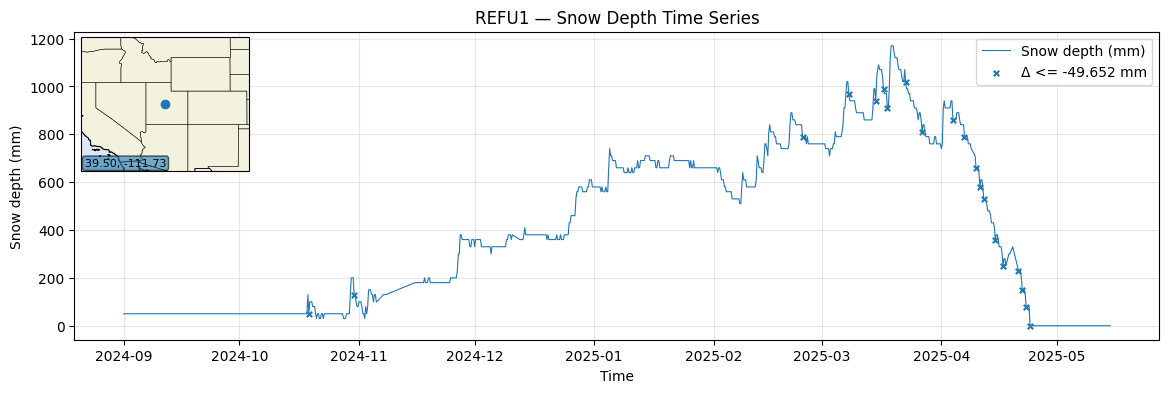

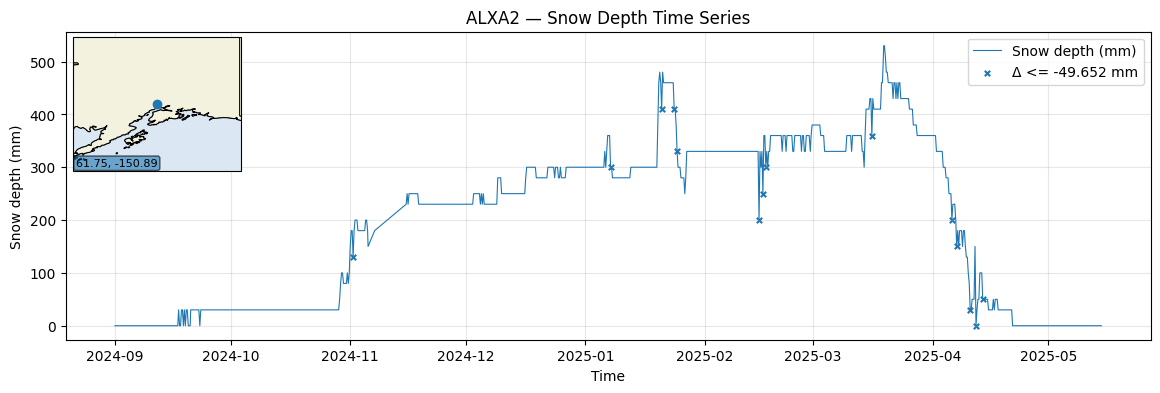

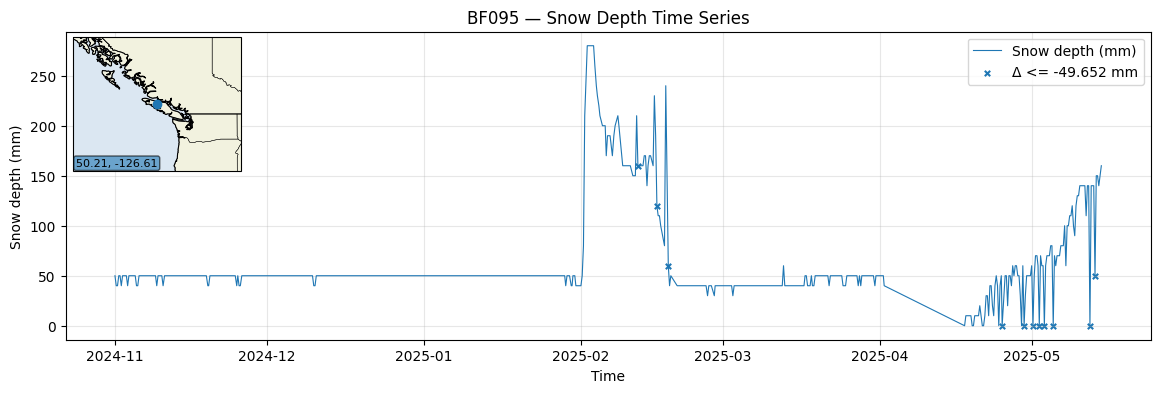

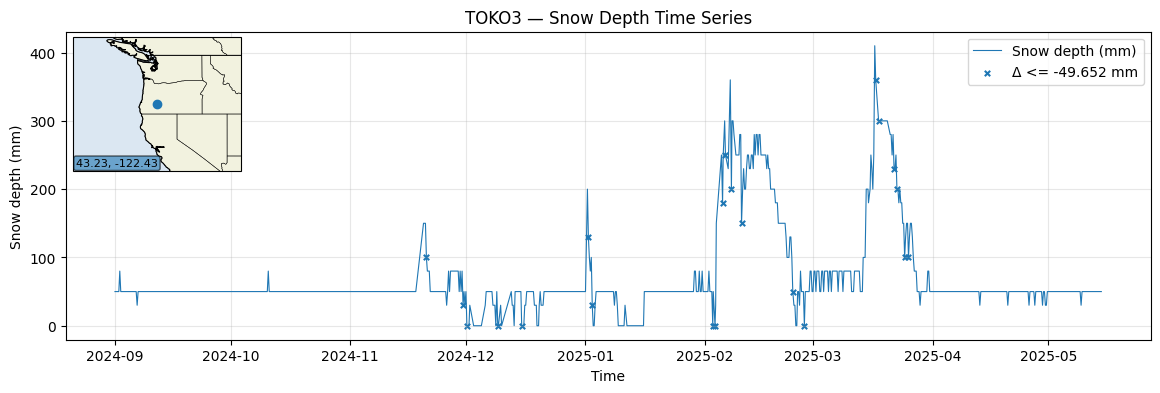

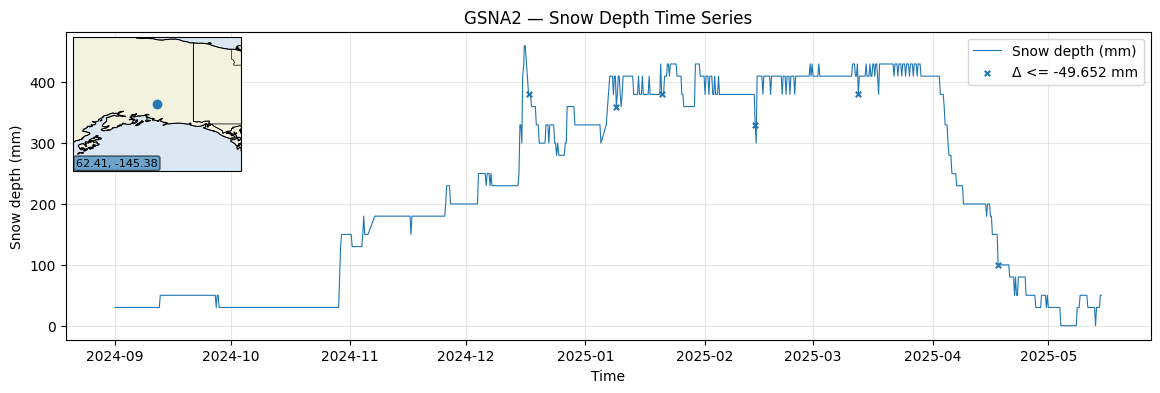

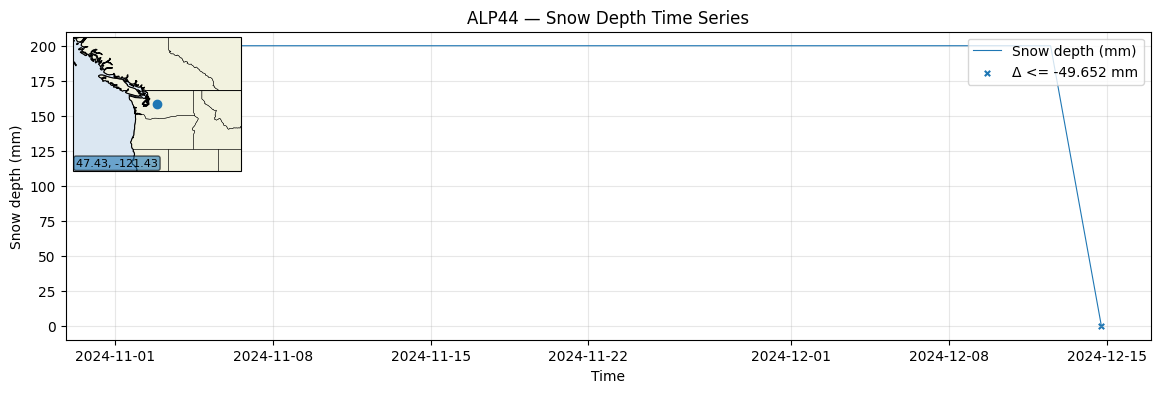

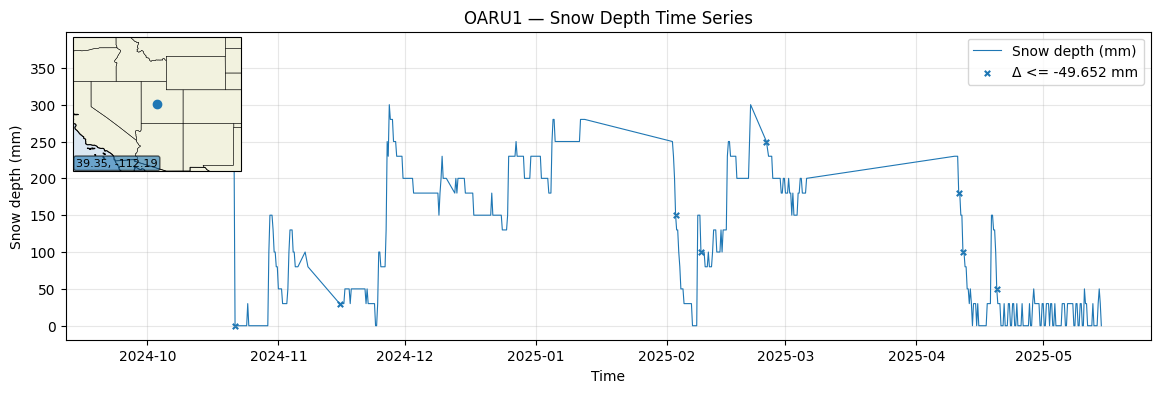

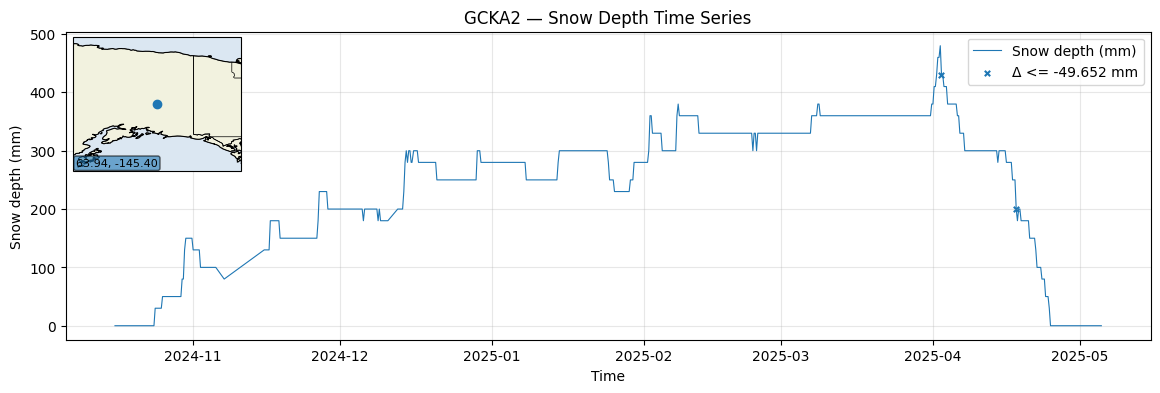

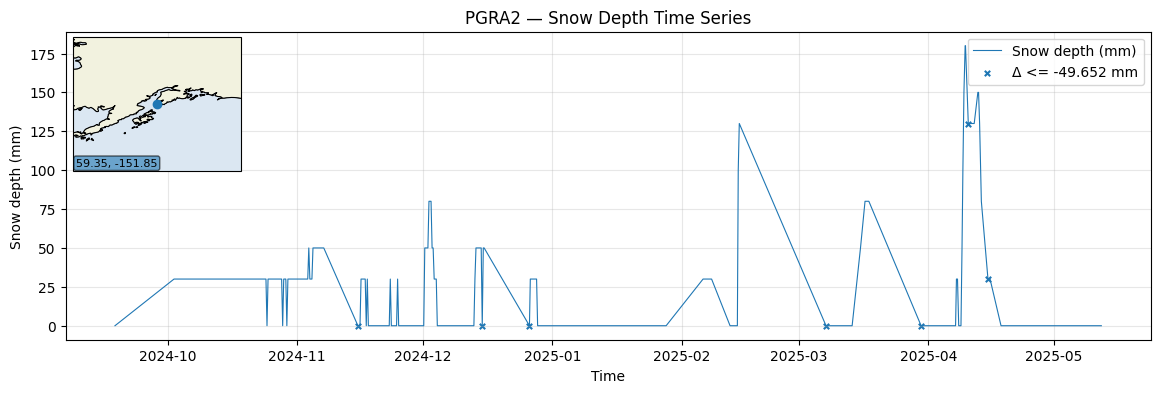

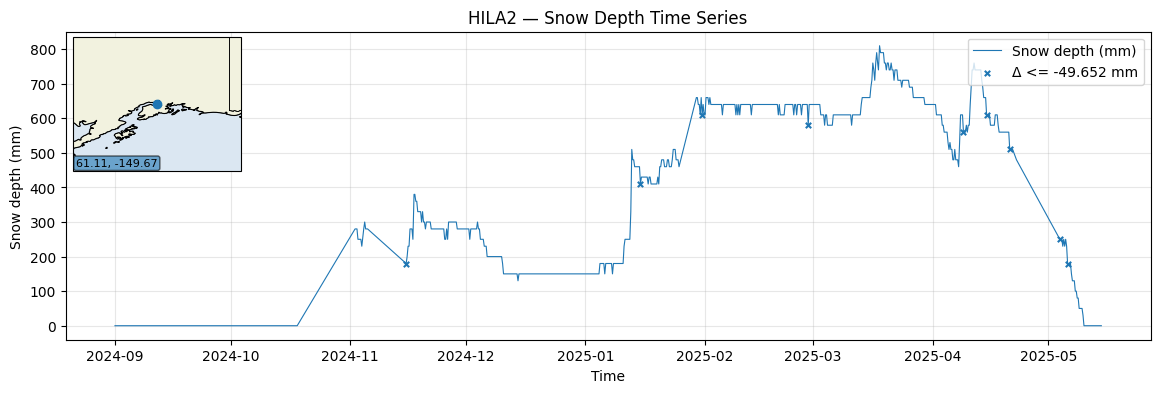

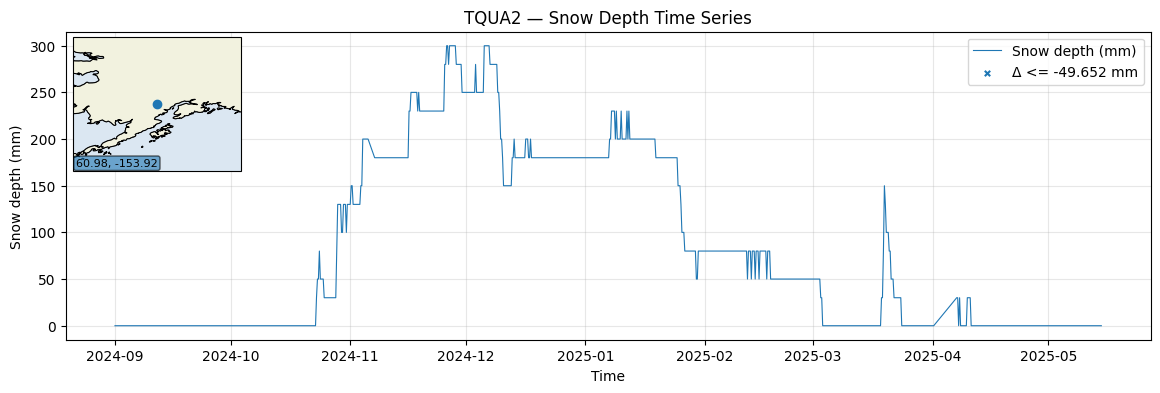

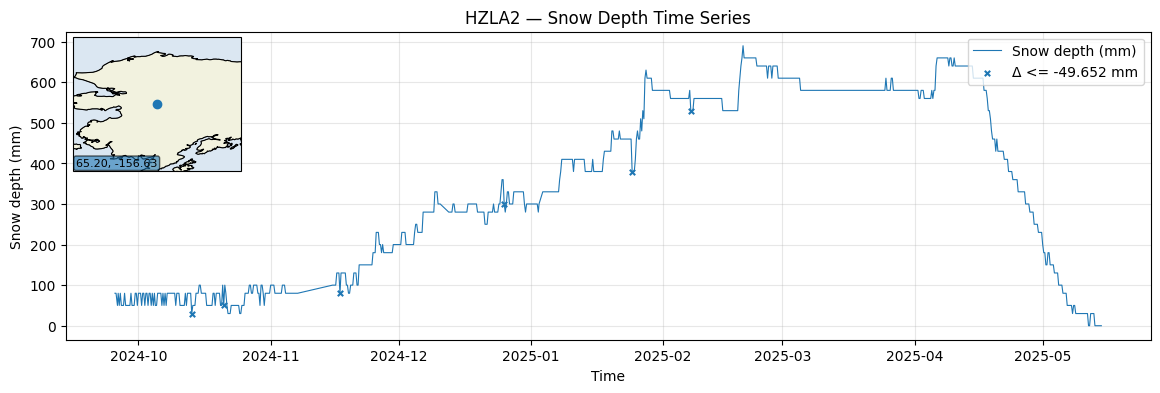

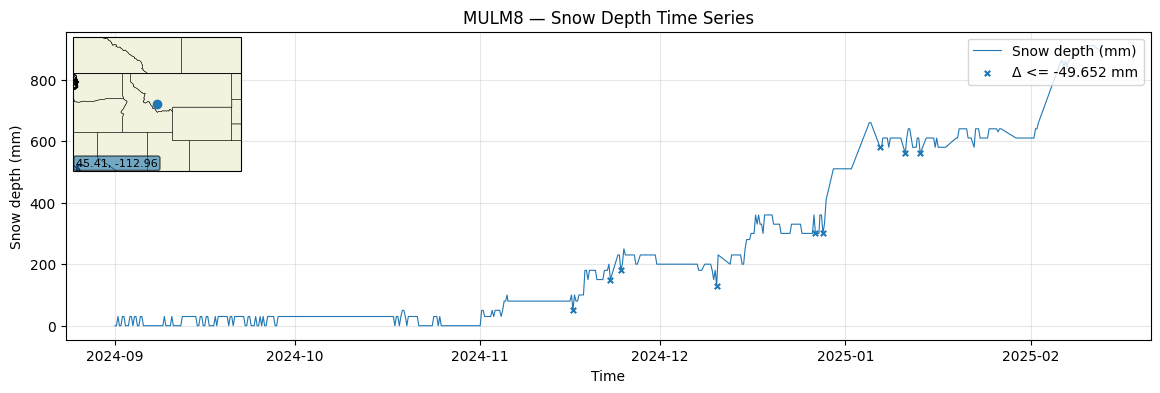

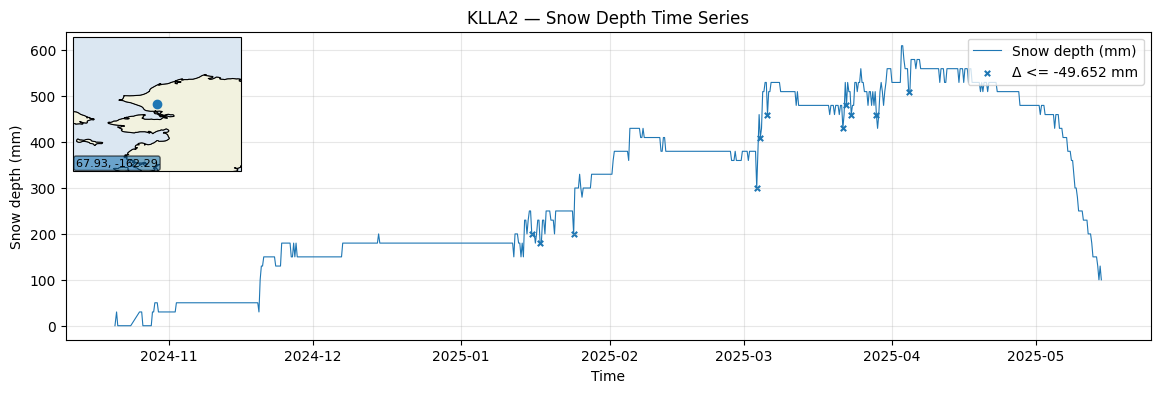

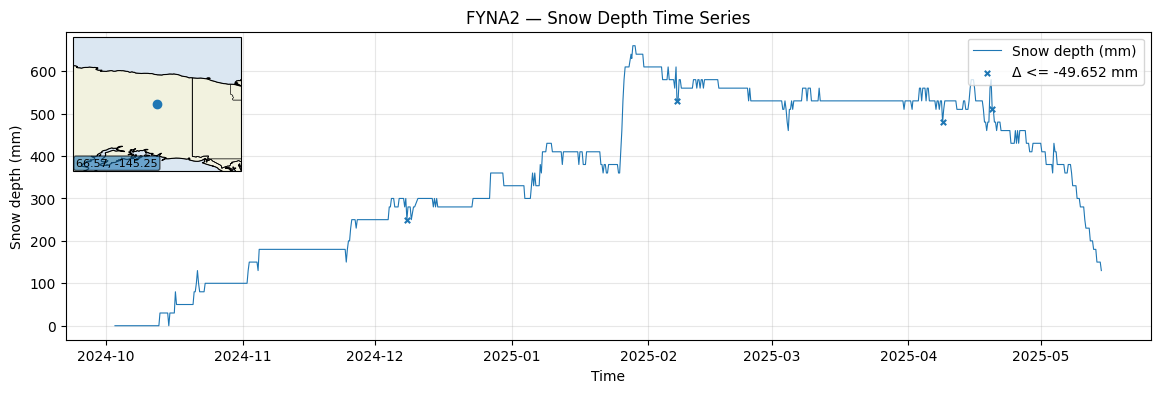

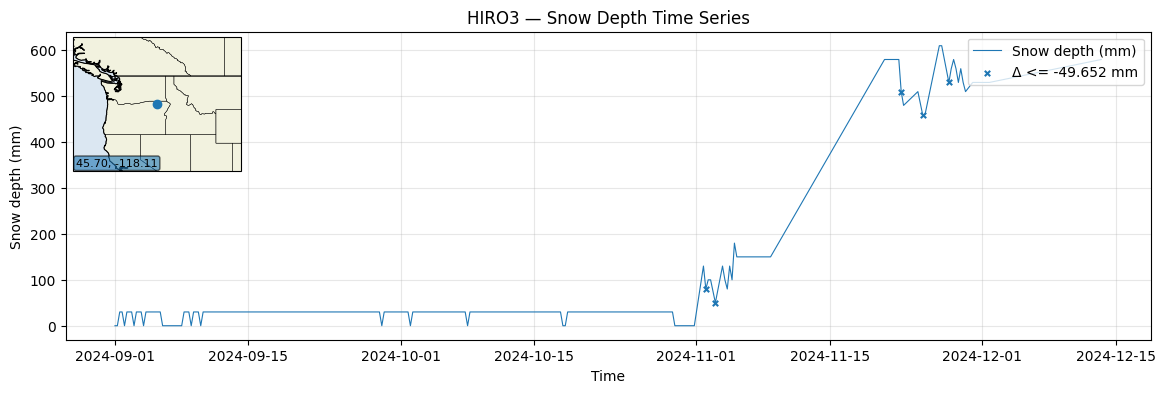

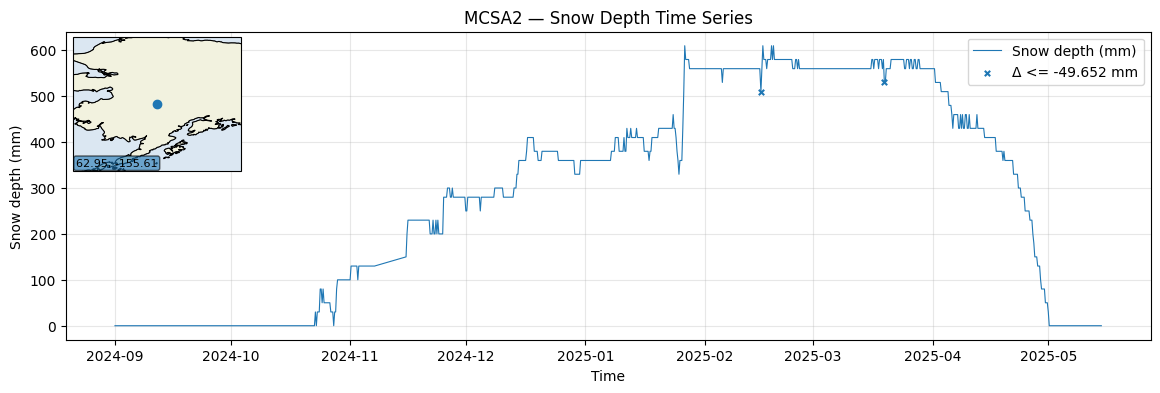

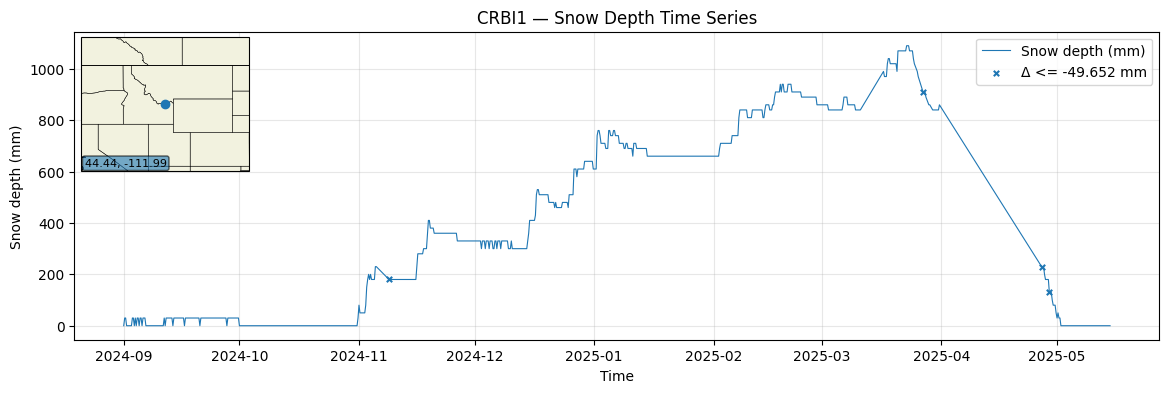

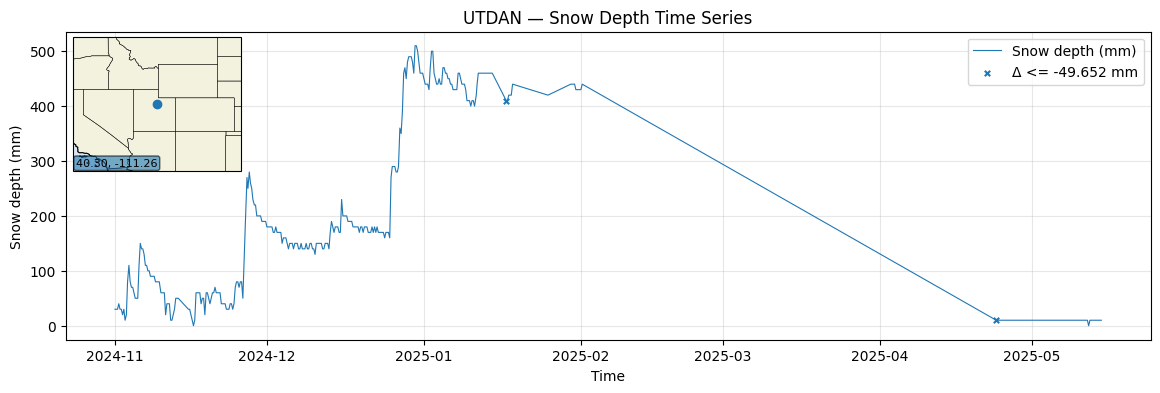

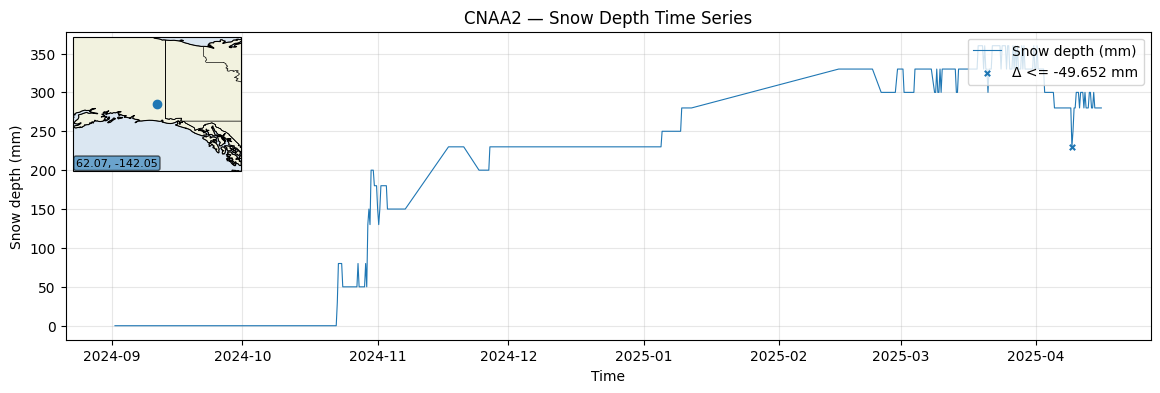

In [22]:
worst_ids = suspects2["station_id"].head(20).tolist()

for stid in worst_ids:
    out_png = f"snomad_snocvr_{stid}_negsteps.png"
    plot_station_timeseries_with_cartopy_map(
        df=analysis_df,                 # your original df is fine
        station_id=stid,
        step_threshold=-49.652,  # use the data-driven threshold
        out_png=out_png
    )